interactive(children=(FloatLogSlider(value=1.0, description='G:', max=1.0, min=-5.0), FloatSlider(value=0.0, d…

<function __main__.update_plot(G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1)>

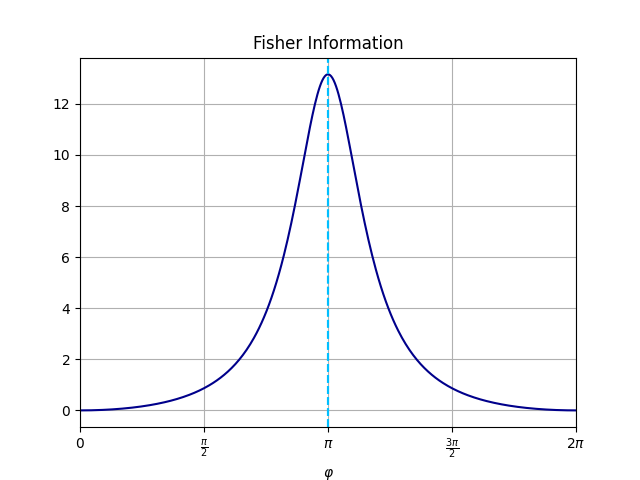

In [ ]:
%matplotlib widget
import numpy as np
from numpy import abs
import matplotlib.pyplot as plt
import ipywidgets as widgets
from OptimalPhase import OptimalPhase

phi = np.linspace(0, 2*np.pi, 400)

fig, ax = plt.subplots()
line1, = ax.plot([], [], color="darkblue")
vline1 = ax.axvline(0, color="deepskyblue", linestyle="--")
vline2 = ax.axvline(0, color="deepskyblue", linestyle="--")

ax.set_title(r'Fisher Information')
ax.set_xlabel(r'$\varphi$')
ax.set_xticks(np.linspace(0, 2*np.pi, 5))
ax.set_xticklabels([0, r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
ax.set_xlim([0, 2*np.pi])
#ax.grid(True)
#ax.legend() 

def update_plot(G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1):

    #? Here, the sliders will no longer represent τ. Instead, they represent T
    t_i1=np.sqrt(t_i1)
    t_s1=np.sqrt(t_s1) 
    t_s2=np.sqrt(t_s2)

    U=np.cosh(G)
    V=np.sinh(G)

    #* Average number of output signal photons (no seed): <N_{s2}^{α=0}>
    N0 = abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi)))    

    #* Average number of output signal photons (seed): <N_{s2}^{α}>
    Na= abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+(1+abs(a_i)**2)*abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi)))  

    #* Inverse of Propagation of Errors: 1/<(Δφ)^2>
    num = 4*abs(t_s2)**4*abs(t_s1)**2*abs(t_i1)**2 * abs(U)**4*abs(V)**4 * (1+abs(a_i)**2)**2 * np.sin(phi)**2
    dnum = N0*(1+N0) + (Na-N0)*(1+2*N0)
    Fc = num / dnum

    phi0 = OptimalPhase(a_i=a_i, G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2)

    line1.set_data(phi, Fc)
    vline1.set_xdata([phi0])
    vline2.set_xdata([2*np.pi-phi0])

    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw()

G = widgets.FloatLogSlider(value=1.0, base=10, min=-5, max=1, step=0.1, description='G:')
a_i = widgets.FloatSlider(value=0.0, min=0, max=10, step=0.5, description='α:')
t_i1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='Tᵢ₁:')
t_s1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='Tₛ₁:')
t_s2 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='Tₛ₂:')

widgets.interact(update_plot, G=G, a_i=a_i, t_i1=t_i1, t_s1=t_s1, t_s2=t_s2)